# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [110]:
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)

print(f'Rows: {raw_data.shape[0]}')

Rows: 7214


In [111]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [112]:
df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
               'priors_count', 'days_b_screening_arrest', 'decile_score',
               'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']].copy()

# Apply all 4 filters
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']

df = df.reset_index(drop=True)

print(f'Rows after filtering: {len(df)}')

Rows after filtering: 6172


In [113]:
# crime_factor
df['crime_factor'] = df['c_charge_degree'].astype('category')

# age_factor: reference level = '25 - 45'
df['age_factor'] = pd.Categorical(df['age_cat'],
                                   categories=['25 - 45', 'Greater than 45', 'Less than 25'])

# race_factor: reference level = 'Caucasian'
df['race_factor'] = pd.Categorical(df['race'],
                                    categories=['Caucasian', 'African-American', 'Asian',
                                                'Hispanic', 'Native American', 'Other'])

# gender_factor: reference level = 'Male'
df['gender_factor'] = pd.Categorical(df['sex'], categories=['Male', 'Female'])

# score_factor: Low → LowScore, Medium/High → HighScore
df['score_factor'] = pd.Categorical(
    df['score_text'].apply(lambda x: 'LowScore' if x == 'Low' else 'HighScore'),
    categories=['LowScore', 'HighScore']
)

df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore
5,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,F,25 - 45,Other,Male,LowScore


In [114]:
print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns)}')
print()
print(df.dtypes)

Rows: 6,172
Columns: 18

age                           int64
c_charge_degree              object
race                         object
age_cat                      object
score_text                   object
sex                          object
priors_count                  int64
days_b_screening_arrest     float64
decile_score                  int64
is_recid                      int64
two_year_recid                int64
c_jail_in                    object
c_jail_out                   object
crime_factor               category
age_factor                 category
race_factor                category
gender_factor              category
score_factor               category
dtype: object


Higher COMPAS scores are slightly correlated with a longer length of stay.

In [115]:
df['length_of_stay'] = (pd.to_datetime(df['c_jail_out']).dt.date - pd.to_datetime(df['c_jail_in']).dt.date).apply(lambda x: x.days if pd.notnull(x) else None)

print(df['length_of_stay'].corr(df['decile_score']))

0.2073296916147045


After filtering we have the following demographic breakdown:

In [116]:
print(df['age_cat'].value_counts().sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [117]:
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [118]:
n = len(df)
race_counts = df['race'].value_counts()

print(f"Black defendants: {race_counts.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants: {race_counts.get('Caucasian', 0) / n * 100:.2f}%")
print(f"Hispanic defendants: {race_counts.get('Hispanic', 0) / n * 100:.2f}%")
print(f"Asian defendants: {race_counts.get('Asian', 0) / n * 100:.2f}%")
print(f"Native American defendants: {race_counts.get('Native American', 0) / n * 100:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [119]:
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [120]:
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [121]:
print(df['sex'].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [122]:
sex_counts = df['sex'].value_counts()
n = len(df)

print("Men: %.2f%%" % (sex_counts['Male'] / n * 100))
print("Women: %.2f%%" % (sex_counts['Female'] / n * 100))

Men: 80.96%
Women: 19.04%


In [123]:
print(len(df[df['two_year_recid'] == 1]))

2809


In [124]:
print("%.5f" % (len(df[df['two_year_recid'] == 1]) / len(df) * 100))

45.51199


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

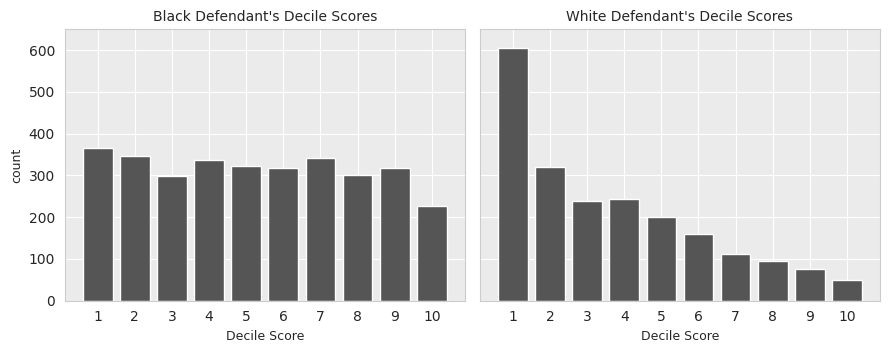

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.63), sharey=True)

for ax, race, title in zip(
    axes,
    ['African-American', 'Caucasian'],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"]
):
    counts = df[df['race'] == race]['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color='#555555', width=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Decile Score", fontsize=9)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))
    ax.set_facecolor('#EBEBEB')
    ax.grid(True, color='white', linewidth=0.8)

axes[0].set_ylabel("count", fontsize=9)

plt.tight_layout()
plt.show()

In [126]:
xtab = pd.crosstab(df['decile_score'], df['race'])[['African-American', 'Asian', 'Caucasian', 'Hispanic', 'Native American', 'Other']]
print(xtab.to_string())

race          African-American  Asian  Caucasian  Hispanic  Native American  Other
decile_score                                                                      
1                          365     15        605       159                0    142
2                          346      4        321        89                2     60
3                          298      5        238        73                1     32
4                          337      0        243        47                0     39
5                          323      1        200        39                0     19
6                          318      2        160        27                2     20
7                          343      1        113        28                2      9
8                          301      2         96        14                0      7
9                          317      0         77        17                2      7
10                         227      1         50        16                2      8


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [127]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)
df['two_year_recid'] = df['two_year_recid'].astype('category')

model_glm = smf.logit(
    'score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid',
    data=df
).fit()

order = ['Intercept', 'gender_factor[T.Female]', 'age_factor[T.Greater than 45]',
         'age_factor[T.Less than 25]', 'race_factor[T.African-American]',
         'race_factor[T.Asian]', 'race_factor[T.Hispanic]',
         'race_factor[T.Native American]', 'race_factor[T.Other]',
         'priors_count', 'crime_factor[T.M]', 'two_year_recid[T.1]']

summary = model_glm.summary2().tables[1].loc[order]
print(summary[['Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]']].to_string())

print(f'\nNull deviance: {-2 * model_glm.llnull:.1f}  on {int(model_glm.nobs) - 1}  degrees of freedom')
print(f'Residual deviance: {-2 * model_glm.llf:.1f}  on {int(model_glm.df_resid)}  degrees of freedom')
print(f'AIC: {model_glm.aic:.1f}')
print(f'\nNumber of Fisher Scoring iterations: 5')

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                                    Coef.  Std.Err.          z          P>|z|    [0.025    0.975]
Intercept                       -1.525538  0.078515 -19.430004   4.303325e-84 -1.679424 -1.371653
gender_factor[T.Female]          0.221267  0.079510   2.782870   5.388046e-03  0.065429  0.377104
age_factor[T.Greater than 45]   -1.355633  0.099081 -13.682110   1.298682e-42 -1.549828 -1.161439
age_factor[T.Less than 25]       1.308390  0.075929  17.231823   1.532449e-66  1.159573  1.457208
race_factor[T.African-American]  0.477207  0.069349   6.881220   5.934215e-12  0.341285  0.613129
race_factor[T.Asian]            -0.254415  0.478211  -0.532013   5.947169e-01 -1.191692  0.682862
race_factor[T.Hispanic]         -0.428395  0.128126  -3.343555   8.271232e-04 -0.679516 -0.177273
race_factor[T.Native American]   1.394208  0.766119   1.819833   6.878450e-02 -0.107357  2.895773
race_factor[T.Ot

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [128]:
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
print("%.6f" % (np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))))

1.452841


Women are 19.4% more likely than men to get a higher score.

In [129]:
print("%.6f" % (np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))))

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [130]:
print("%.5f" % (np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))))

2.49612


In [131]:
# Generate predicted probabilities and classes
df['pred_prob']  = model_glm.predict()
df['pred_class'] = df['pred_prob'].apply(lambda x: 'Recid' if x >= 0.5 else 'No Recid')

# Overall Confusion Matrix
df['actual'] = df['two_year_recid'].astype(int)
df['pred']   = (df['pred_class'] == 'Recid').astype(int)

TP = ((df['pred'] == 1) & (df['actual'] == 1)).sum()
TN = ((df['pred'] == 0) & (df['actual'] == 0)).sum()
FP = ((df['pred'] == 1) & (df['actual'] == 0)).sum()
FN = ((df['pred'] == 0) & (df['actual'] == 1)).sum()
n  = TP + TN + FP + FN

cm = pd.DataFrame(
    [[TN, FN], [FP, TP]],
    index   = pd.Index(['No Recid', 'Recid'], name='Predicted'),
    columns = pd.Index([0, 1], name='Actual')
)

print('\n── Overall Confusion Matrix ──────────────────────────────────────────')
print(cm)
print(f'\nAccuracy  : {(TP + TN) / n:.3f}')
print(f'Precision : {TP / (TP + FP):.3f}')
print(f'Recall    : {TP / (TP + FN):.3f}')
print(f'FPR       : {FP / (FP + TN):.3f}')
print(f'FNR       : {FN / (FN + TP):.3f}')


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [133]:
print('\n── Confusion Matrix by Race ──────────────────────────────────────────')

race_rows = []
for race, grp in df.groupby('race'):
    TP = ((grp['pred'] == 1) & (grp['actual'] == 1)).sum()
    TN = ((grp['pred'] == 0) & (grp['actual'] == 0)).sum()
    FP = ((grp['pred'] == 1) & (grp['actual'] == 0)).sum()
    FN = ((grp['pred'] == 0) & (grp['actual'] == 1)).sum()
    n  = len(grp)
    race_rows.append({
        'race'     : race,
        'n'        : n,
        'TP'       : TP,
        'TN'       : TN,
        'FP'       : FP,
        'FN'       : FN,
        'Accuracy' : round((TP + TN) / n, 3),
        'Precision': round(TP / (TP + FP), 3) if (TP + FP) > 0 else None,
        'Recall'   : round(TP / (TP + FN), 3) if (TP + FN) > 0 else None,
        'FPR'      : round(FP / (FP + TN), 3) if (FP + TN) > 0 else None,
        'FNR'      : round(FN / (FN + TP), 3) if (FN + TP) > 0 else None,
    })

race_metrics = pd.DataFrame(race_rows).sort_values('n', ascending=False).reset_index(drop=True)
race_metrics.index = race_metrics.index + 1
print(race_metrics.to_string())


── Confusion Matrix by Race ──────────────────────────────────────────
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall    FPR    FNR
1  African-American  3175  1373   959  555  288     0.734      0.712   0.827  0.367  0.173
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464  0.104  0.536
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429  0.044  0.571
4             Other   343    22   216    3  102     0.694      0.880   0.177  0.014  0.823
5             Asian    31     2    22    1    6     0.774      0.667   0.250  0.043  0.750
6   Native American    11     5     2    4    0     0.636      0.556   1.000  0.667  0.000


In [132]:
print('\n── FPR and FNR Disparity by Race ─────────────────────────────────────')

caucasian_FPR = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
caucasian_FNR = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - caucasian_FPR).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - caucasian_FNR).round(3)

print(disparity.to_string())


── FPR and FNR Disparity by Race ─────────────────────────────────────
               race     n    FPR    FNR  delta_FPR  delta_FNR
1  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
4             Other   343  0.014  0.823     -0.090      0.287
5             Asian    31  0.043  0.750     -0.061      0.214
6   Native American    11  0.667  0.000      0.563     -0.536
